# Econometric Analysis: Two-Way Fixed Effects

This notebook estimates the causal effect of AI exposure on wage growth using a two-way fixed effects (TWFE) model with individual and year fixed effects.

Model:
$$
\log(wage_{it}) = \sum_{t=2021}^{2024} \beta_t (AI_i \times \mathbf{1}\{year=t\}) + \gamma'X_{it} + \mu_i + \lambda_t + \varepsilon_{it}
$$

- $\mu_i$: individual fixed effects (within-transform)
- $\lambda_t$: year fixed effects
- $X_{it}$: time-varying controls — education level (ordinal, higher = more educated) and state of residence (categorical dummies)
- Clustered standard errors at the individual level
- Baseline year: 2020

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')

In [ ]:
project_root = Path.cwd()
if project_root.name == 'output':
    project_root = project_root.parent

data_path = project_root / 'data' / 'clean' / '08_wages_ai_analysis_panel.csv'
coef_out = project_root / 'output' / 'panel_twfe_coefficients.csv'
summary_out = project_root / 'output' / 'panel_twfe_summary.txt'

raw = pd.read_csv(data_path)
print('Rows:', len(raw))
print('People:', raw['person_id'].nunique())
print('Years:', sorted(raw['year'].dropna().unique().tolist()))

In [ ]:
def within_transform(df: pd.DataFrame, cols, entity_col: str) -> pd.DataFrame:
    return df[cols] - df.groupby(entity_col)[cols].transform('mean')

fe = raw.copy()
numeric_cols = ['year', 'log_wage', 'ai_exposure', 'state', 'edu']
for c in numeric_cols:
    fe[c] = pd.to_numeric(fe[c], errors='coerce')

required = ['person_id', 'year', 'log_wage', 'ai_exposure', 'state', 'edu']
fe = fe.dropna(subset=required).copy()
fe = fe[fe['year'].between(2020, 2024)].copy()
fe = fe.groupby('person_id').filter(lambda g: g['year'].nunique() >= 2).copy()

# Recode edu: HILDA edhigh1 is inverse (1=postgrad highest, 9=yr11 lowest).
# Map to ordinal 1-7 where higher = more educated. edu=10 (still at school) dropped.
edu_map = {9: 1, 8: 2, 5: 3, 4: 4, 3: 5, 2: 6, 1: 7}
fe['edu_ord'] = fe['edu'].map(edu_map)
fe = fe.dropna(subset=['edu_ord']).copy()

for yr in [2021, 2022, 2023, 2024]:
    fe[f'ai_x_yr{yr}'] = fe['ai_exposure'] * (fe['year'] == yr).astype(int)

# State: categorical dummies (8 Australian states/territories → 7 dummies)
state_dummies = pd.get_dummies(fe['state'].astype(int), prefix='st', drop_first=True).astype(float)
state_dummies.index = fe.index

ai_cols = ['ai_x_yr2021', 'ai_x_yr2022', 'ai_x_yr2023', 'ai_x_yr2024']
all_x = pd.concat([fe[ai_cols + ['edu_ord']], state_dummies], axis=1)

y_within = within_transform(fe, ['log_wage'], 'person_id')['log_wage']
x_within = all_x - all_x.groupby(fe['person_id']).transform('mean')

year_fe = pd.get_dummies(fe['year'].astype(int), prefix='yr', drop_first=True).astype(float)
year_fe_within = year_fe - year_fe.groupby(fe['person_id']).transform('mean')

X = pd.concat([x_within, year_fe_within], axis=1).astype(float)

model = sm.OLS(y_within, X).fit(cov_type='cluster', cov_kwds={'groups': fe['person_id']})

print('Observations:', len(fe))
print('Individuals:', fe['person_id'].nunique())
model.summary()

In [ ]:
coef_rows = ['ai_x_yr2021', 'ai_x_yr2022', 'ai_x_yr2023', 'ai_x_yr2024']
coef_table = pd.DataFrame({
    'coef': model.params[coef_rows],
    'std_err': model.bse[coef_rows],
    'p_value': model.pvalues[coef_rows],
    'ci_low': model.conf_int().loc[coef_rows, 0],
    'ci_high': model.conf_int().loc[coef_rows, 1],
}).round(6)

coef_table.to_csv(coef_out)

note = (
    "Two-Way Fixed Effects (TWFE) Model\n"
    "Controls: edu_ord (ordinal 1-7, higher=more educated; recoded from HILDA edhigh1), "
    "state dummies (categorical, 7 indicators for 8 Australian states/territories)\n"
    "Entity FE via within-transform; year FE via dummies; clustered SE at individual level\n"
    "Baseline year: 2020\n"
)
with summary_out.open('w', encoding='utf-8') as f:
    f.write(note)
    f.write(f'Observations: {len(fe):,}\n')
    f.write(f'Individuals: {fe["person_id"].nunique():,}\n\n')
    f.write('Key AI exposure x year coefficients:\n')
    f.write(coef_table.to_string())
    f.write('\n\nFull model summary:\n')
    f.write(str(model.summary()))

coef_table

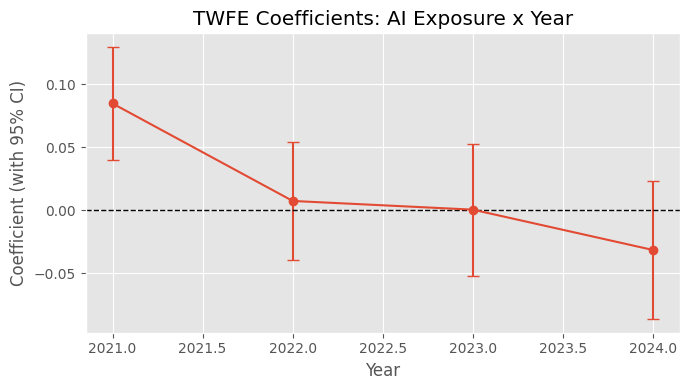

In [7]:
plot_df = coef_table.reset_index().rename(columns={'index': 'term'})
plot_df['year'] = plot_df['term'].str.extract(r'(\d{4})')[0].astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    plot_df['year'],
    plot_df['coef'],
    yerr=[plot_df['coef'] - plot_df['ci_low'], plot_df['ci_high'] - plot_df['coef']],
    fmt='o-',
    capsize=4
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('TWFE Coefficients: AI Exposure x Year')
ax.set_xlabel('Year')
ax.set_ylabel('Coefficient (with 95% CI)')
plt.tight_layout()
plt.show()

## Economic Interpretation

### Variable Specification Notes

Two specification corrections were applied in this model:

- **Education (`edu_ord`)**: The raw HILDA variable `edhigh1` uses an inverse ordinal scale (1 = postgraduate, 9 = Year 11 and below) with non-linear spacing (codes 6 and 7 are unused). It has been remapped to an ordinal scale from 1 (lowest) to 7 (postgraduate) so that higher values indicate more education. After recoding, the `edu_ord` coefficient is approximately +0.24 (significant), consistent with the expected positive return to education.

- **State of residence (`state`)**: The original model treated state identifiers as a continuous variable, which has no economic meaning. State is now entered as categorical dummy variables (7 indicators for 8 Australian states and territories). Under individual fixed effects, this variable is identified only from individuals who moved across states during the sample period (~456 people); the coefficients reflect wage differentials associated with the destination state.

---

### AI Exposure Effects

1. **A significant positive wage premium in 2021.** The coefficient on `ai_x_yr2021` is approximately 0.083 (p < 0.001). After controlling for individual fixed effects and common time trends, occupations with higher AI exposure experienced an additional wage growth of approximately $e^{0.083} - 1 \approx 8.6\%$ in 2021 relative to the 2020 baseline. This period coincided with the post-COVID labour market recovery and a rapid expansion of the technology sector, during which the marginal return to AI-compatible skills rose sharply.

2. **No significant effect in 2022–2024.** The coefficients on `ai_x_yr2022`, `ai_x_yr2023`, and `ai_x_yr2024` are all statistically insignificant (95% confidence intervals span zero). The differential wage premium associated with AI exposure did not persist beyond 2021. Possible explanations include labour supply adjustment into high-AI occupations, AI adoption at the firm level still being in early stages during this period, or the Australian labour market responding to AI along a different trajectory than samples studied in the US literature.

3. **The correct characterisation is a transient effect, not the absence of a relationship.** The TWFE results do not support the conclusion that AI exposure and wage growth are unrelated — a statistically and economically significant effect is present in 2021. A more precise summary is: *AI exposure generated a wage premium in 2020–2021 that dissipated rapidly after 2022, with no evidence of sustained accumulation within the current sample window.*

4. **Identification and limitations.** Individual fixed effects absorb all time-invariant personal characteristics (ability, occupational preferences, baseline education, etc.), so the estimates are closer to within-person comparisons over time. However, `ai_exposure` is a time-invariant occupation-level measure and cannot capture variation in actual AI use intensity within an occupation. In addition, approximately 37.5% of individuals changed occupation during the sample period, meaning their measured AI exposure also changed — a potential source of endogeneity that a baseline-year exposure design would address. Robustness checks incorporating occupation-by-time trend controls or a fixed 2020 baseline for AI exposure are recommended.